# Sparse Feature Allocation with the Indian Buffet Process in PySparkPlug

A lot of real data is not a single label. A shopping basket contains many products. A customer has many interests. A server request trips many flags. A document uses many themes. Those features are sparse and non-exclusive: most possible features are absent, but more than one can be present at the same time.

That is the sweet spot for the Indian buffet process (IBP). In PySparkPlug, `mixle.stats.ibp` implements a finite Beta-Bernoulli truncation of the IBP:

$$
\pi_k \sim \mathrm{Beta}(\alpha / K, 1), \qquad
z_{nk} \mid \pi_k \sim \mathrm{Bernoulli}(\pi_k), \qquad k = 1, \ldots, K.
$$

`K` is the truncation level, `alpha` controls expected row width, and `z_n` is a binary feature row. PySparkPlug fits a variational/conjugate posterior

$$
q(\pi_k) = \mathrm{Beta}(a_k, b_k)
$$

from observed binary rows. The result can score new rows, generate synthetic rows, run in the vectorized estimation path, and compose with the rest of PySparkPlug: mixtures, composites, Gaussian fields, categorical fields, sequences, and distributed back ends.

This notebook is written as an article-style walkthrough. It starts with the mechanics, then uses a real public retail dataset to model market baskets as sparse feature allocations.


## Latent features and the Indian buffet process

A basket (or customer) can be described by a set of latent binary features (preferences, personas), but
their number is unknown. The Indian buffet process (IBP) is a prior over binary feature-assignment
matrices with infinitely many potential features, of which only finitely many are active in any finite
dataset.

Definition (IBP). Customers enter a buffet with infinitely many dishes. The first takes
$\mathrm{Poisson}(\alpha)$ dishes; customer $i$ takes each previously chosen dish $k$ with probability
$m_k/i$ (proportional to its current popularity $m_k$) and then $\mathrm{Poisson}(\alpha/i)$ brand-new
dishes. This "rich get richer" rule induces an exchangeable distribution over binary feature matrices.

Theorem (Beta-Bernoulli limit and feature count). The IBP is the infinite limit of a finite
Beta-Bernoulli feature model: place $\pi_k\sim\mathrm{Beta}(\alpha/K,1)$ on each of $K$ features and let
$K\to\infty$. The expected number of active features after $n$ customers is $\alpha H_n\approx\alpha\log n$,
and the total number of feature-instantiations is $\mathrm{Poisson}(\alpha H_n)$. So $\alpha$ controls
model complexity, which grows logarithmically, mirroring the Dirichlet-process cluster count (the
conjugate-Bayes notebook).

## Exchangeability, conjugacy, and a limitation

Exchangeability and de Finetti. The IBP feature matrix is exchangeable in the customers, so by a de
Finetti argument it is a mixture of iid feature draws over a latent measure; that measure is the Beta
process, the IBP's continuous mixing distribution. This is what makes posterior inference coherent as more
data arrive.

Conjugate updating. With Bernoulli observations per feature and a Beta prior, the per-feature posterior is
Beta with hyperparameters updated by adding the observed counts (the exponential-families notebook), so
each product's purchase-probability posterior is available in closed form, with credible intervals, as the
applied section reports.

Counterexample (features are assumed independent given the latent). The IBP feature model treats features
as independent given their probabilities, so it does not directly capture correlations among co-purchased
items beyond what shared features explain. Strongly correlated complements (items almost always bought
together) may be split across features or need a correlated-feature extension. The lift analysis in the
applied section measures exactly these residual pairwise correlations.

## What this notebook builds

We will use the UCI Online Retail II dataset: invoices from a UK-based online retailer between 2009 and 2011. Each invoice becomes a sparse binary row over the top product codes: item present or item absent.

The experiments:

1. Fit a single IBP to real market baskets.
2. Interpret posterior product probabilities and uncertainty intervals.
3. Score unusual baskets after controlling for basket size.
4. Sample posterior-predictive baskets and check what the model captures or misses.
5. Change the observational unit from invoice to customer.
6. Compose IBP with a Gaussian in a mixture model to learn basket personas.
7. Close with practical guidance: when this model is useful, and when it is too simple.

Dataset attribution: Chen, D. (2012). Online Retail II [Dataset]. UCI Machine Learning Repository. DOI: 10.24432/C5CG6D (https://doi.org/10.24432/C5CG6D). The current UCI page lists the dataset under CC BY 4.0 (https://archive.ics.uci.edu/dataset/502/online%2Bretail%2Bii).


## Setup

The notebook reads prepared CSV/JSON artifacts from `../../data/online_retail_ii/`:

- `transactions_top150.csv`: one row per invoice, with sparse item indices;
- `items_top150.csv`: item index to stock code and description;
- `manifest.json`: source, license, and preprocessing notes;
- `prepare_online_retail_ii.py`: reproducible conversion script from the UCI workbook.

The raw UCI zip is also stored in that folder. Normal notebook execution only needs the compact prepared artifacts.


In [1]:
import io
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

# Prefer the sibling local checkout when this notebook is run from mixle-notebooks/.
for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    candidate = base / 'mixle'
    if (candidate / 'mixle').exists():
        sys.path.insert(0, str(candidate))
        break
    sibling = base.parent / 'mixle'
    if (sibling / 'mixle').exists():
        sys.path.insert(0, str(sibling))
        break

from mixle.stats import *
from mixle.inference import seq_initialize, seq_estimate, initialize
from mixle.inference.estimation import optimize

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 90)
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.RandomState(2026)


In [2]:
def find_online_retail_dir():
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates = [
            base / 'data' / 'online_retail_ii',
            base.parent / 'data' / 'online_retail_ii',
            base / 'mixle-notebooks' / 'data' / 'online_retail_ii',
            base.parent / 'mixle-notebooks' / 'data' / 'online_retail_ii',
        ]
        for candidate in candidates:
            if (candidate / 'transactions_top150.csv').exists():
                return candidate
    raise FileNotFoundError('Could not find data/online_retail_ii/transactions_top150.csv')


def parse_indices(value):
    if pd.isna(value) or str(value).strip() == '':
        return []
    return [int(x) for x in str(value).split()]


def fit_ibp(data, num_features, alpha, estimate_alpha=False, pseudo_count=None,
            suff_stat=None, data_format='sparse'):
    est = IndianBuffetProcessEstimator(
        num_features,
        alpha=alpha,
        estimate_alpha=estimate_alpha,
        pseudo_count=pseudo_count,
        suff_stat=suff_stat,
        data_format=data_format,
    )
    enc = seq_encode(data, estimator=est)
    return seq_initialize(enc, est, np.random.RandomState(123), p=1.0)


def finite_alpha_for_width(width, num_features):
    # Solve width = K * alpha / (K + alpha) for alpha.
    width = min(float(width), num_features - 1.0e-9)
    return width * num_features / (num_features - width)


def posterior_summary(model, item_table, ci=0.90):
    a = model.beta_params[:, 0]
    b = model.beta_params[:, 1]
    lo = beta_dist.ppf((1.0 - ci) / 2.0, a, b)
    hi = beta_dist.ppf(1.0 - (1.0 - ci) / 2.0, a, b)
    out = item_table[['item_index', 'stock_code', 'description', 'invoice_count']].copy()
    out['post_mean'] = model.feature_probs
    out['ci_low'] = lo
    out['ci_high'] = hi
    out['posterior_a'] = a
    out['posterior_b'] = b
    return out


def basket_names(indices, item_table, max_items=10):
    names = item_table.set_index('item_index').loc[list(indices), 'description'].tolist() if len(indices) else []
    if len(names) > max_items:
        return '; '.join(names[:max_items]) + f'; ... (+{len(names) - max_items} more)'
    return '; '.join(names)


def rows_to_binary_matrix(rows, num_features):
    mat = np.zeros((len(rows), num_features), dtype=int)
    for i, row in enumerate(rows):
        if row:
            mat[i, row] = 1
    return mat


def score_rows(model, rows):
    enc = model.dist_to_encoder().seq_encode(rows)
    return model.seq_log_density(enc)


def describe_low_rows(frame, item_table, n=8):
    cols = ['invoice_id', 'invoice_date', 'country', 'top_item_count', 'total_revenue',
            'log_density', 'size_adjusted_residual', 'items']
    return frame.sort_values('size_adjusted_residual').head(n)[cols]


## 1. Load the real sparse-basket dataset

The raw workbook has over a million line items. The preparation script keeps positive sales, removes obvious service/adjustment lines, chooses the top 150 products by invoice frequency, and represents each invoice by the subset of those top products that appeared.

That means each observation is naturally sparse. Instead of a 150-length vector like `[0, 0, 1, ...]`, a basket is stored as active indices like `[2, 17, 44]`.


In [3]:
DATA_DIR = find_online_retail_dir()
transactions = pd.read_csv(DATA_DIR / 'transactions_top150.csv')
items = pd.read_csv(DATA_DIR / 'items_top150.csv')
manifest = json.loads((DATA_DIR / 'manifest.json').read_text())

transactions['active_indices'] = transactions['active_indices'].map(parse_indices)
transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])
transactions['log_revenue'] = np.log1p(transactions['total_revenue'])
K = len(items)

print('data dir:', DATA_DIR)
print('source:', manifest['source']['citation'])
print('license:', manifest['source']['license'])
print('prepared transactions:', len(transactions))
print('features/products:', K)
print('date range:', transactions.invoice_date.min(), 'to', transactions.invoice_date.max())
print('countries:', transactions.country.nunique(), 'customers:', transactions.customer_id.replace('', np.nan).nunique())

transactions.head()


data dir: /Users/grantboquet/codex/mixle-notebooks/data/online_retail_ii
source: Chen, D. (2012). Online Retail II [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D.
license: Creative Commons Attribution 4.0 International (CC BY 4.0)
prepared transactions: 32957
features/products: 150
date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
countries: 43 customers: 5458


,invoice_id,invoice_date,country,customer_id,line_count,distinct_products,total_quantity,total_revenue,active_indices,top_item_count,log_revenue
0,489434,2009-12-01 07:45:00,United Kingdom,13085.0,8,8,166,505.30,"[7, 127]",2,6.227129
1,489436,2009-12-01 09:06:00,United Kingdom,13078.0,19,19,193,630.33,"[5, 21, 37, 45, 46]",5,6.447829
2,489437,2009-12-01 09:08:00,United Kingdom,15362.0,23,23,145,310.75,"[43, 46, 58, 116]",4,5.742202
3,489438,2009-12-01 09:24:00,United Kingdom,18102.0,17,17,826,2286.24,[147],1,7.735101
4,489439,2009-12-01 09:28:00,France,12682.0,18,18,216,372.30,"[19, 31, 56, 129]",4,5.922382


,top_item_count,distinct_products,total_quantity,total_revenue
count,32957.00,32957.00,32957.00,32957.00
mean,7.14,29.12,292.55,552.09
std,8.28,45.08,580.83,1207.23
min,1.00,1.00,1.00,0.42
25%,2.00,10.00,88.00,190.53
50%,5.00,18.00,172.00,319.97
75%,9.00,32.00,314.00,539.18
max,125.00,1105.00,25018.00,52940.94


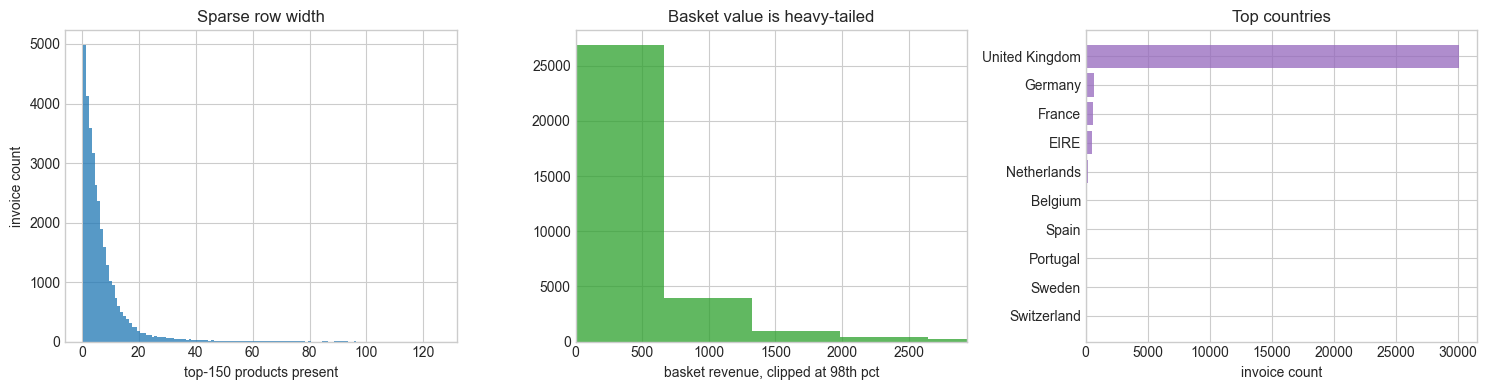

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(transactions['top_item_count'], bins=np.arange(1, transactions['top_item_count'].max() + 2) - 0.5,
             color='tab:blue', alpha=0.75)
axes[0].set_xlabel('top-150 products present')
axes[0].set_ylabel('invoice count')
axes[0].set_title('Sparse row width')

axes[1].hist(transactions['total_revenue'], bins=80, color='tab:green', alpha=0.75)
axes[1].set_xlim(0, transactions['total_revenue'].quantile(0.98))
axes[1].set_xlabel('basket revenue, clipped at 98th pct')
axes[1].set_title('Basket value is heavy-tailed')

country_counts = transactions['country'].value_counts().head(10).sort_values()
axes[2].barh(country_counts.index, country_counts.values, color='tab:purple', alpha=0.75)
axes[2].set_xlabel('invoice count')
axes[2].set_title('Top countries')
plt.tight_layout()

transactions[['top_item_count', 'distinct_products', 'total_quantity', 'total_revenue']].describe().round(2)


The target variable is not a category. Each basket can contain any subset of the 150 top products. That is why a categorical distribution would be the wrong object: it forces exactly one state. A Bernoulli feature allocation keeps the multi-product structure.


## 2. The IBP update in one cell

For observed binary rows, this finite IBP has a simple posterior update. If product `k` appears in `m_k` of `N` baskets, then without extra pseudocounts:

$$
a_k = \alpha / K + m_k, \qquad b_k = 1 + N - m_k.
$$

The posterior mean is `a_k / (a_k + b_k)`. The estimator also stores expected-log terms used by `expected_log_density`.

We choose `alpha` by matching the prior expected row width to the training-set average width under the finite truncation:

$$
E[\#\text{active features}] = K\frac{\alpha}{K + \alpha}.
$$


In [5]:
# Chronological split: train on the earlier 80%, score the later 20%.
cut = int(0.80 * len(transactions))
train_tx = transactions.iloc[:cut].copy()
test_tx = transactions.iloc[cut:].copy()
train_rows = train_tx['active_indices'].tolist()
test_rows = test_tx['active_indices'].tolist()

mean_width = np.mean([len(row) for row in train_rows])
alpha0 = finite_alpha_for_width(mean_width, K)

basket_model = fit_ibp(train_rows, K, alpha=alpha0, estimate_alpha=False, data_format='sparse')
summary = posterior_summary(basket_model, items)
empirical_train = rows_to_binary_matrix(train_rows, K).mean(axis=0)
summary['train_frequency'] = empirical_train

print('training baskets:', len(train_rows))
print('holdout baskets:', len(test_rows))
print('mean active top products per train basket:', round(mean_width, 3))
print('finite-prior alpha chosen for that row width:', round(alpha0, 3))
print('posterior probability vector shape:', basket_model.feature_probs.shape)
summary.sort_values('post_mean', ascending=False).head(12).round(4)


training baskets: 26365
holdout baskets: 6592
mean active top products per train basket: 7.136
finite-prior alpha chosen for that row width: 7.492
posterior probability vector shape: (150,)


,item_index,stock_code,description,invoice_count,post_mean,ci_low,ci_high,posterior_a,posterior_b,train_frequency
0,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5464,0.1798,0.1759,0.1837,4740.0499,21626.0,0.1798
2,2,22423,REGENCY CAKESTAND 3 TIER,3918,0.1245,0.1212,0.1279,3283.0499,23083.0,0.1245
1,1,85099B,JUMBO BAG RED RETROSPOT,4013,0.1227,0.1194,0.1260,3234.0499,23132.0,0.1227
3,3,21212,PACK OF 72 RETROSPOT CAKE CASES,3118,0.1013,0.0982,0.1043,2670.0499,23696.0,0.1013
4,4,20725,LUNCH BAG RED RETROSPOT,3056,0.0958,0.0928,0.0988,2526.0499,23840.0,0.0958
6,6,47566,PARTY BUNTING,2674,0.0853,0.0825,0.0882,2250.0499,24116.0,0.0853
5,5,84879,ASSORTED COLOUR BIRD ORNAMENT,2807,0.0848,0.0820,0.0876,2235.0499,24131.0,0.0848
7,7,21232,STRAWBERRY CERAMIC TRINKET BOX,2435,0.0816,0.0789,0.0844,2152.0499,24214.0,0.0816
8,8,22383,LUNCH BAG SUKI DESIGN,2398,0.0742,0.0715,0.0768,1955.0499,24411.0,0.0742
10,10,21931,JUMBO STORAGE BAG SUKI,2329,0.0735,0.0709,0.0762,1939.0499,24427.0,0.0735


In [6]:
counts = rows_to_binary_matrix(train_rows, K).sum(axis=0)
manual_a = alpha0 / K + counts
manual_b = 1.0 + len(train_rows) - counts

print('max |a - manual_a|:', np.max(np.abs(basket_model.beta_params[:, 0] - manual_a)))
print('max |b - manual_b|:', np.max(np.abs(basket_model.beta_params[:, 1] - manual_b)))


max |a - manual_a|: 0.0
max |b - manual_b|: 0.0


## 3. Product popularity as a posterior, not just a frequency table

The posterior mean is close to empirical frequency because we have many baskets. The useful extra is uncertainty: for very common products the interval is tight; for rare products it stays wider. This matters more when you filter to a niche segment, a short time window, or a new market.


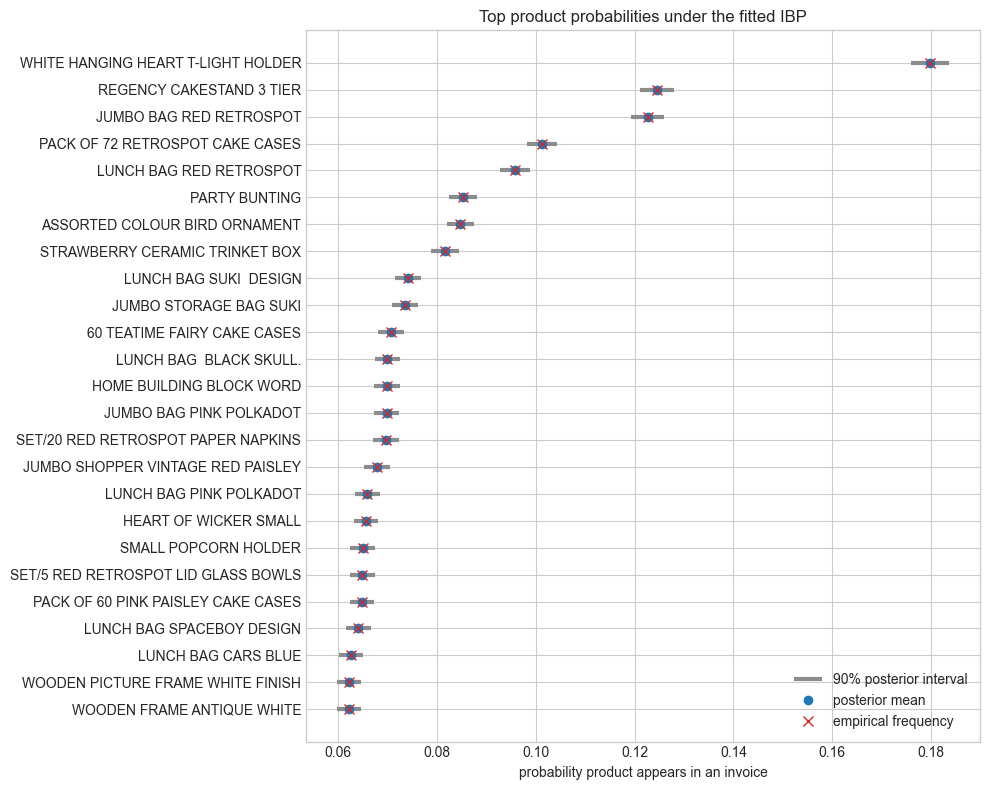

In [7]:
top = summary.sort_values('post_mean', ascending=False).head(25).sort_values('post_mean')
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(10, 8))
ax.hlines(y, top['ci_low'], top['ci_high'], color='0.55', lw=3, label='90% posterior interval')
ax.plot(top['post_mean'], y, 'o', color='tab:blue', label='posterior mean')
ax.plot(top['train_frequency'], y, 'x', color='tab:red', ms=7, label='empirical frequency')
ax.set_yticks(y)
ax.set_yticklabels(top['description'])
ax.set_xlabel('probability product appears in an invoice')
ax.set_title('Top product probabilities under the fitted IBP')
ax.legend(loc='lower right')
plt.tight_layout()


In [8]:
uncertain = summary.assign(interval_width=summary['ci_high'] - summary['ci_low']) \
    .sort_values('interval_width', ascending=False) \
    .head(12)
uncertain[['item_index', 'stock_code', 'description', 'post_mean', 'ci_low', 'ci_high', 'interval_width']].round(4)


,item_index,stock_code,description,post_mean,ci_low,ci_high,interval_width
0,0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.1798,0.1759,0.1837,0.0078
2,2,22423,REGENCY CAKESTAND 3 TIER,0.1245,0.1212,0.1279,0.0067
1,1,85099B,JUMBO BAG RED RETROSPOT,0.1227,0.1194,0.1260,0.0066
3,3,21212,PACK OF 72 RETROSPOT CAKE CASES,0.1013,0.0982,0.1043,0.0061
4,4,20725,LUNCH BAG RED RETROSPOT,0.0958,0.0928,0.0988,0.0060
6,6,47566,PARTY BUNTING,0.0853,0.0825,0.0882,0.0057
5,5,84879,ASSORTED COLOUR BIRD ORNAMENT,0.0848,0.0820,0.0876,0.0056
7,7,21232,STRAWBERRY CERAMIC TRINKET BOX,0.0816,0.0789,0.0844,0.0055
8,8,22383,LUNCH BAG SUKI DESIGN,0.0742,0.0715,0.0768,0.0053
10,10,21931,JUMBO STORAGE BAG SUKI,0.0735,0.0709,0.0762,0.0053


## 4. Scoring baskets: surprise, not judgment

`log_density(row)` gives the fitted probability of a basket under the independent sparse-feature model. Low-density rows are not automatically bad. They are simply unusual under the training distribution.

One complication: larger baskets naturally have lower log density because more feature decisions are being multiplied together. For triage, it is better to compare a row against other rows of similar size. Here we fit a simple quadratic baseline of log density versus basket width on the training set, then use the residual as a size-adjusted surprise score.


holdout mean log density: -29.0
holdout 1% residual cutoff: -5.459


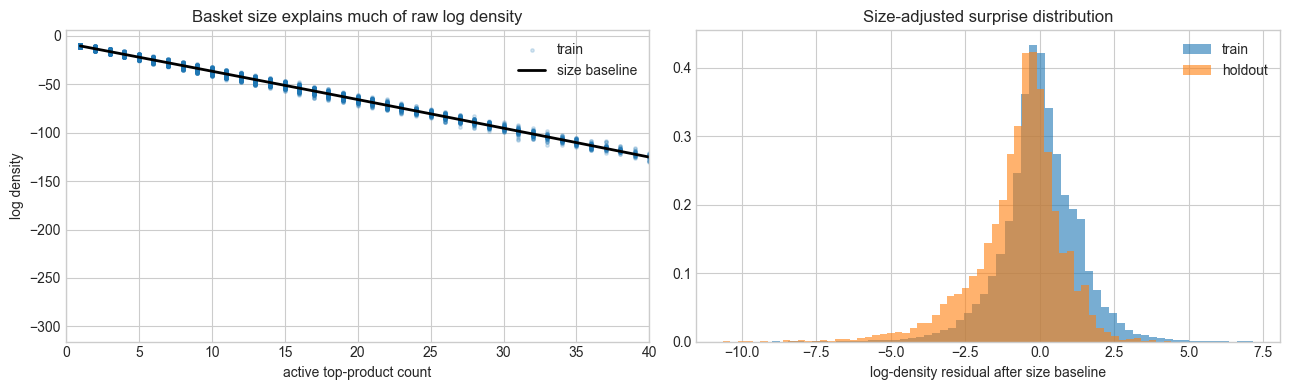

In [9]:
train_scores = score_rows(basket_model, train_rows)
test_scores = score_rows(basket_model, test_rows)
train_counts = train_tx['top_item_count'].to_numpy()
test_counts = test_tx['top_item_count'].to_numpy()

coef = np.polyfit(train_counts, train_scores, deg=2)
train_baseline = np.polyval(coef, train_counts)
test_baseline = np.polyval(coef, test_counts)

train_scored = train_tx.copy()
test_scored = test_tx.copy()
train_scored['log_density'] = train_scores
train_scored['size_adjusted_residual'] = train_scores - train_baseline
test_scored['log_density'] = test_scores
test_scored['size_adjusted_residual'] = test_scores - test_baseline

test_scored['items'] = test_scored['active_indices'].map(lambda row: basket_names(row, items, max_items=8))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(train_counts, train_scores, s=6, alpha=0.18, label='train')
xs = np.linspace(train_counts.min(), np.percentile(train_counts, 99), 200)
axes[0].plot(xs, np.polyval(coef, xs), color='black', lw=2, label='size baseline')
axes[0].set_xlim(0, np.percentile(train_counts, 99))
axes[0].set_xlabel('active top-product count')
axes[0].set_ylabel('log density')
axes[0].set_title('Basket size explains much of raw log density')
axes[0].legend()

axes[1].hist(train_scored['size_adjusted_residual'], bins=60, alpha=0.6, density=True, label='train')
axes[1].hist(test_scored['size_adjusted_residual'], bins=60, alpha=0.6, density=True, label='holdout')
axes[1].set_xlabel('log-density residual after size baseline')
axes[1].set_title('Size-adjusted surprise distribution')
axes[1].legend()
plt.tight_layout()

print('holdout mean log density:', round(float(test_scored.log_density.mean()), 3))
print('holdout 1% residual cutoff:', round(float(test_scored.size_adjusted_residual.quantile(0.01)), 3))


In [10]:
describe_low_rows(test_scored, items, n=10).round({'total_revenue': 2, 'log_density': 2, 'size_adjusted_residual': 2})


,invoice_id,invoice_date,country,top_item_count,total_revenue,log_density,size_adjusted_residual,items
30217,574298,2011-11-03 15:56:00,United Kingdom,58,2593.37,-190.49,-10.63,WHITE HANGING HEART T-LIGHT HOLDER; JUMBO BAG RED RETROSPOT; PACK OF 72 RETROSPOT CAKE...
30469,574941,2011-11-07 17:42:00,United Kingdom,26,52940.94,-93.30,-9.95,SMALL POPCORN HOLDER; HEART OF WICKER SMALL; PAPER CHAIN KIT 50'S CHRISTMAS; HEART OF ...
29605,572550,2011-10-24 17:06:00,United Kingdom,48,2101.21,-159.20,-9.86,JUMBO BAG RED RETROSPOT; JUMBO STORAGE BAG SUKI; SMALL POPCORN HOLDER; HEART OF WICKER...
31008,576365,2011-11-14 17:55:00,United Kingdom,25,50653.91,-90.07,-9.68,SMALL POPCORN HOLDER; HEART OF WICKER SMALL; PAPER CHAIN KIT 50'S CHRISTMAS; VINTAGE S...
30899,576052,2011-11-13 14:48:00,United Kingdom,21,368.79,-77.88,-9.30,SET/20 RED RETROSPOT PAPER NAPKINS; SET/5 RED RETROSPOT LID GLASS BOWLS; BAKING SET 9 ...
31389,577358,2011-11-18 15:59:00,United Kingdom,73,5370.16,-235.53,-9.28,WHITE HANGING HEART T-LIGHT HOLDER; PACK OF 72 RETROSPOT CAKE CASES; LUNCH BAG RED RET...
31954,578844,2011-11-25 16:14:00,United Kingdom,70,4142.94,-225.44,-8.53,WHITE HANGING HEART T-LIGHT HOLDER; JUMBO BAG RED RETROSPOT; REGENCY CAKESTAND 3 TIER;...
31169,576840,2011-11-16 15:23:00,United Kingdom,74,4674.63,-237.87,-8.50,WHITE HANGING HEART T-LIGHT HOLDER; JUMBO BAG RED RETROSPOT; REGENCY CAKESTAND 3 TIER;...
30815,575875,2011-11-11 13:06:00,United Kingdom,66,4116.75,-212.97,-8.46,PACK OF 72 RETROSPOT CAKE CASES; LUNCH BAG RED RETROSPOT; STRAWBERRY CERAMIC TRINKET B...
28639,569846,2011-10-06 13:42:00,United Kingdom,21,2626.30,-76.82,-8.25,LUNCH BAG CARS BLUE; SET/5 RED RETROSPOT LID GLASS BOWLS; LUNCH BAG WOODLAND; VINTAGE ...


Those rows are good candidates for review because their composition is surprising for their size. In a production setting this could feed a dashboard, a recommendation sanity check, or an alert queue. The model is not accusing any invoice of being wrong; it is saying: "this combination is rare under the historical sparse-feature distribution."


## 5. Posterior predictive check: what does the IBP capture?

A fitted distribution is also a generator. If the model is a useful summary of the data, synthetic baskets sampled from it should resemble real baskets on the statistics it claims to model.

This IBP should capture marginal product popularity and approximate row width. It should not capture product-to-product dependence very well, because conditional on the feature probabilities, items are independent.


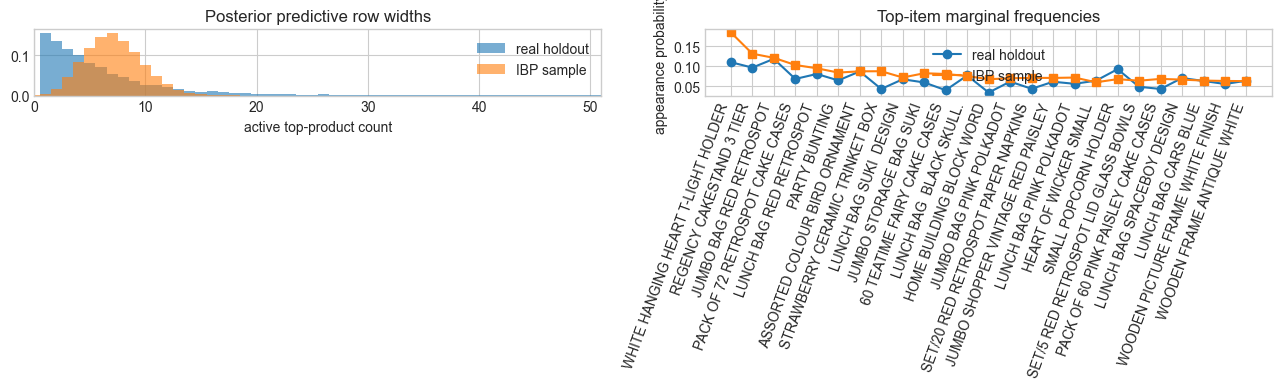

In [11]:
synthetic_rows = basket_model.sampler(seed=99).sample(size=len(test_rows))
synthetic_counts = np.asarray([len(row) for row in synthetic_rows])
test_mat = rows_to_binary_matrix(test_rows, K)
synth_mat = rows_to_binary_matrix(synthetic_rows, K)

test_freq = test_mat.mean(axis=0)
synth_freq = synth_mat.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.arange(0, max(test_counts.max(), synthetic_counts.max()) + 2) - 0.5
axes[0].hist(test_counts, bins=bins, alpha=0.6, density=True, label='real holdout')
axes[0].hist(synthetic_counts, bins=bins, alpha=0.6, density=True, label='IBP sample')
axes[0].set_xlim(0, np.percentile(test_counts, 99))
axes[0].set_xlabel('active top-product count')
axes[0].set_title('Posterior predictive row widths')
axes[0].legend()

plot_idx = summary.sort_values('post_mean', ascending=False).head(25)['item_index'].to_numpy()
axes[1].plot(test_freq[plot_idx], 'o-', label='real holdout')
axes[1].plot(synth_freq[plot_idx], 's-', label='IBP sample')
axes[1].set_xticks(np.arange(len(plot_idx)))
axes[1].set_xticklabels(items.loc[plot_idx, 'description'], rotation=70, ha='right')
axes[1].set_ylabel('appearance probability')
axes[1].set_title('Top-item marginal frequencies')
axes[1].legend()
plt.tight_layout()


In [12]:
def pair_stats(mat, i, j):
    pi = mat[:, i].mean()
    pj = mat[:, j].mean()
    pij = (mat[:, i] & mat[:, j]).mean()
    independent = pi * pj
    lift = pij / independent if independent > 0 else np.nan
    return pi, pj, pij, independent, lift

candidate_pairs = [
    (1, 10),   # jumbo bags
    (4, 8),    # lunch bags
    (3, 17),   # paper/cake cases and napkins
    (21, 45),  # building block words
    (0, 2),    # heart holder and cakestand
]

pair_rows = []
for i, j in candidate_pairs:
    pi, pj, pij, independent, lift = pair_stats(rows_to_binary_matrix(train_rows, K).astype(bool), i, j)
    pair_rows.append({
        'item_a': items.loc[i, 'description'],
        'item_b': items.loc[j, 'description'],
        'P(a)': pi,
        'P(b)': pj,
        'observed_P(a,b)': pij,
        'IBP_independent_P(a)P(b)': independent,
        'observed_lift': lift,
    })

pd.DataFrame(pair_rows).round(4)


,item_a,item_b,P(a),P(b),"observed_P(a,b)",IBP_independent_P(a)P(b),observed_lift
0,JUMBO BAG RED RETROSPOT,JUMBO STORAGE BAG SUKI,0.1227,0.0735,0.0409,0.0090,4.5324
1,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN,0.0958,0.0742,0.0360,0.0071,5.0612
2,PACK OF 72 RETROSPOT CAKE CASES,SET/20 RED RETROSPOT PAPER NAPKINS,0.1013,0.0697,0.0256,0.0071,3.6230
3,HOME BUILDING BLOCK WORD,LOVE BUILDING BLOCK WORD,0.0699,0.0576,0.0297,0.0040,7.3923
4,WHITE HANGING HEART T-LIGHT HOLDER,REGENCY CAKESTAND 3 TIER,0.1798,0.1245,0.0253,0.0224,1.1284


This table is the honest limitation. A single IBP is excellent as a sparse-feature marginal model. It is not a full market-basket association model. If co-occurrence patterns are central, you can use a mixture of IBP components, add other structured fields, or pair this with association-rule / graphical-model machinery.


## 6. Same model, different observational unit: customers instead of invoices

An invoice row answers: "which products appeared in this basket?" A customer row answers: "which products has this customer ever bought?" Both are sparse binary feature-allocation questions, but the posterior probabilities have different meanings.


In [13]:
customer_tx = transactions.loc[transactions['customer_id'].astype(str).str.len() > 0].copy()
customer_records = []
for customer_id, group in customer_tx.groupby('customer_id'):
    active = sorted(set(idx for row in group['active_indices'] for idx in row))
    if active:
        customer_records.append({
            'customer_id': customer_id,
            'active_indices': active,
            'invoice_count': len(group),
            'total_revenue': group['total_revenue'].sum(),
            'top_item_count': len(active),
            'country': group['country'].mode().iloc[0],
        })
customers = pd.DataFrame(customer_records)
customer_rows = customers['active_indices'].tolist()
customer_alpha = finite_alpha_for_width(customers['top_item_count'].mean(), K)
customer_model = fit_ibp(customer_rows, K, alpha=customer_alpha, estimate_alpha=False, data_format='sparse')
customer_summary = posterior_summary(customer_model, items).rename(columns={'post_mean': 'customer_ever_bought_prob'})
invoice_summary = summary[['item_index', 'post_mean']].rename(columns={'post_mean': 'invoice_appearance_prob'})
level_compare = customer_summary.merge(invoice_summary, on='item_index')
level_compare['ratio_customer_to_invoice'] = (
    level_compare['customer_ever_bought_prob'] / level_compare['invoice_appearance_prob']
)

print('customers:', len(customers))
print('mean active top products per customer:', round(customers.top_item_count.mean(), 2))
print('customer-level alpha:', round(customer_alpha, 2))
level_compare.sort_values('customer_ever_bought_prob', ascending=False) \
    [['stock_code', 'description', 'customer_ever_bought_prob', 'invoice_appearance_prob', 'ratio_customer_to_invoice']] \
    .head(15).round(3)


customers: 5458
mean active top products per customer: 15.76
customer-level alpha: 17.61


,stock_code,description,customer_ever_bought_prob,invoice_appearance_prob,ratio_customer_to_invoice
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.273,0.180,1.518
2,22423,REGENCY CAKESTAND 3 TIER,0.241,0.125,1.933
31,22138,BAKING SET 9 PIECE RETROSPOT,0.208,0.054,3.889
3,21212,PACK OF 72 RETROSPOT CAKE CASES,0.204,0.101,2.017
5,84879,ASSORTED COLOUR BIRD ORNAMENT,0.185,0.085,2.183
1,85099B,JUMBO BAG RED RETROSPOT,0.179,0.123,1.461
19,22139,RETROSPOT TEA SET CERAMIC 11 PC,0.172,0.061,2.809
26,22086,PAPER CHAIN KIT 50'S CHRISTMAS,0.164,0.042,3.927
6,47566,PARTY BUNTING,0.164,0.085,1.919
15,22469,HEART OF WICKER SMALL,0.162,0.066,2.472


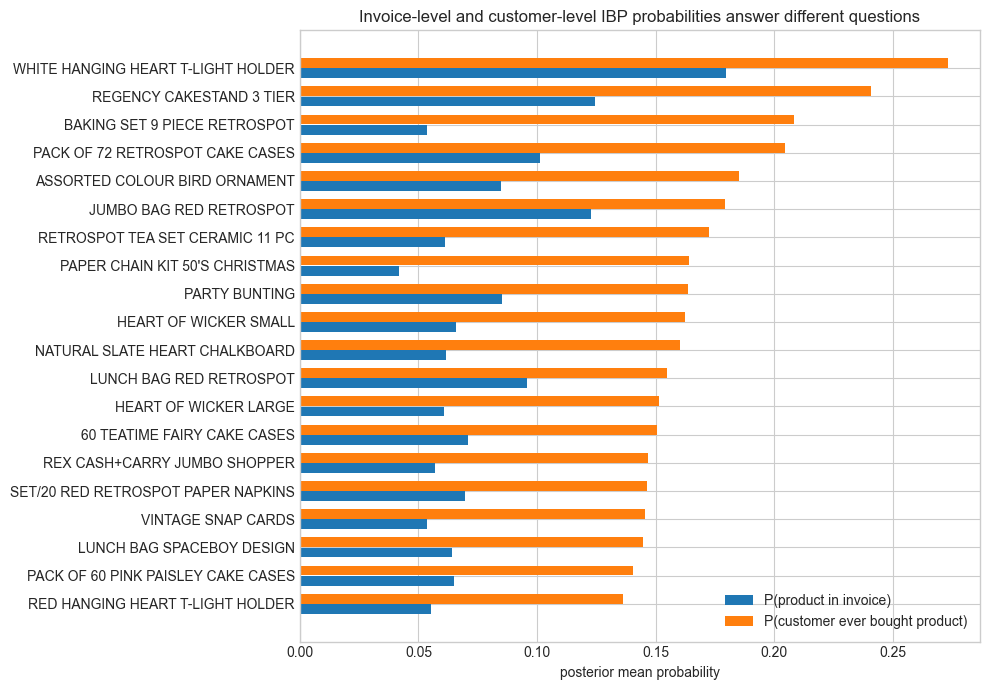

In [14]:
top_customer = level_compare.sort_values('customer_ever_bought_prob', ascending=False).head(20).sort_values('customer_ever_bought_prob')
y = np.arange(len(top_customer))
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y - 0.18, top_customer['invoice_appearance_prob'], height=0.35, label='P(product in invoice)')
ax.barh(y + 0.18, top_customer['customer_ever_bought_prob'], height=0.35, label='P(customer ever bought product)')
ax.set_yticks(y)
ax.set_yticklabels(top_customer['description'])
ax.set_xlabel('posterior mean probability')
ax.set_title('Invoice-level and customer-level IBP probabilities answer different questions')
ax.legend()
plt.tight_layout()


The same `IndianBuffetProcessEstimator` did both jobs. Only the row construction changed. This is the practical trick: once you can express a problem as sparse multi-feature rows, the IBP gives you a compact probabilistic summary.


## 7. Composing IBP with other fields: basket personas

The rest of PySparkPlug becomes useful when the sparse row is only part of the record. Here each observation is

```python
(active product indices, log basket revenue)
```

and we fit a three-component mixture of composite distributions:

$$
p(x, r) = \sum_c w_c\; p(x \mid c, \mathrm{IBP})\;p(r \mid c, \mathrm{Gaussian}).
$$

This model learns basket personas: components with different product profiles and different revenue scales.


In [15]:
mix_sample_size = 12_000
mix_idx = np.sort(RNG.choice(len(train_tx), size=mix_sample_size, replace=False))
mix_data = [
    (train_rows[i], float(train_tx.iloc[i]['log_revenue']))
    for i in mix_idx
]

component_estimator = CompositeEstimator((
    IndianBuffetProcessEstimator(K, alpha=alpha0, estimate_alpha=False, pseudo_count=1.0, data_format='sparse'),
    GaussianEstimator(),
))
mixture_estimator = MixtureEstimator([component_estimator, component_estimator, component_estimator], pseudo_count=2.0)

log_capture = io.StringIO()
persona_model = optimize(
    mix_data,
    mixture_estimator,
    max_its=30,
    init_p=0.25,
    rng=np.random.RandomState(5),
    out=log_capture,
    print_iter=10,
)

print('\n'.join(log_capture.getvalue().strip().split('\n')[-4:]))
print('mixture weights:', np.round(persona_model.w, 3))


Iteration 10: ln[p_mat(Data|Model)]=-3.255864e+05, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.530211e+01
Iteration 20: ln[p_mat(Data|Model)]=-3.255552e+05, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.329672e+00
Iteration 30: ln[p_mat(Data|Model)]=-3.255430e+05, ln[p_mat(Data|Model)]-ln[p_mat(Data|PrevModel)]=1.217357e+00
mixture weights: [0.162 0.347 0.49 ]


In [16]:
component_order = np.argsort([component.dists[1].mu for component in persona_model.components])
overall_probs = basket_model.feature_probs
component_rows = []
profile_rows = []

for rank, comp_idx in enumerate(component_order):
    component = persona_model.components[comp_idx]
    ibp = component.dists[0]
    gaussian = component.dists[1]
    probs = ibp.feature_probs
    lift = probs / np.maximum(overall_probs, 1.0e-12)
    top_prob_idx = np.argsort(probs)[-8:][::-1]
    top_lift_idx = np.argsort(lift)[-8:][::-1]
    label = f'component_{rank + 1}'
    component_rows.append({
        'component': label,
        'mixture_weight': persona_model.w[comp_idx],
        'expected_revenue_scale_expm1_mu': np.expm1(gaussian.mu),
        'log_revenue_mu': gaussian.mu,
        'log_revenue_sigma': np.sqrt(gaussian.sigma2),
        'expected_active_products': probs.sum(),
    })
    profile_rows.append({
        'component': label,
        'top_probability_items': '; '.join(items.loc[top_prob_idx, 'description']),
        'most_component_specific_items': '; '.join(items.loc[top_lift_idx, 'description']),
    })

component_table = pd.DataFrame(component_rows)
profile_table = pd.DataFrame(profile_rows)
display(component_table.round(3))
display(profile_table)


,component,mixture_weight,expected_revenue_scale_expm1_mu,log_revenue_mu,log_revenue_sigma,expected_active_products
0,component_1,0.490,236.810,5.471,1.068,3.878
1,component_2,0.347,337.314,5.824,0.651,5.636
2,component_3,0.162,685.898,6.532,0.919,19.968


,component,top_probability_items,most_component_specific_items
0,component_1,REGENCY CAKESTAND 3 TIER; JUMBO BAG RED RETROSPOT; PACK OF 72 RETROSPOT CAKE CASES; WH...,PLASTERS IN TIN CIRCUS PARADE; LUNCH BAG VINTAGE DOILY; PLASTERS IN TIN SPACEBOY; SET ...
1,component_2,WHITE HANGING HEART T-LIGHT HOLDER; ASSORTED COLOUR BIRD ORNAMENT; REGENCY CAKESTAND 3...,WOOD 2 DRAWER CABINET WHITE FINISH; WOOD S/3 CABINET ANT WHITE FINISH; LOVE BUILDING B...
2,component_3,JUMBO BAG RED RETROSPOT; LUNCH BAG RED RETROSPOT; JUMBO STORAGE BAG SUKI; LUNCH BAG SU...,JUMBO BAG SPACEBOY DESIGN; JUMBO STORAGE BAG SUKI; CHARLOTTE BAG PINK POLKADOT; JUMBO ...


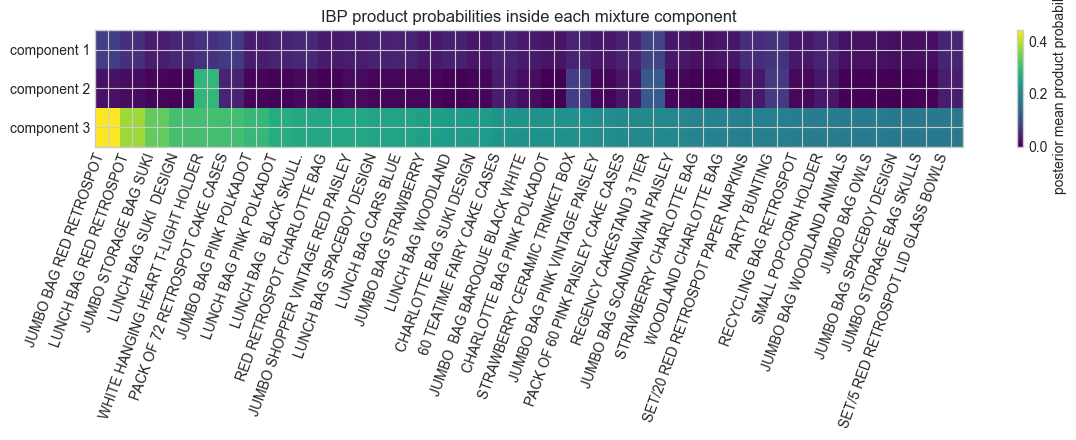

In [17]:
component_prob_matrix = np.vstack([
    persona_model.components[i].dists[0].feature_probs for i in component_order
])
# Plot the 35 items with highest max component probability.
plot_items = np.argsort(component_prob_matrix.max(axis=0))[-35:][::-1]

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(component_prob_matrix[:, plot_items], aspect='auto', vmin=0.0, vmax=component_prob_matrix[:, plot_items].max(), cmap='viridis')
ax.set_yticks(np.arange(len(component_order)))
ax.set_yticklabels([f'component {i + 1}' for i in range(len(component_order))])
ax.set_xticks(np.arange(len(plot_items)))
ax.set_xticklabels(items.loc[plot_items, 'description'], rotation=70, ha='right')
ax.set_title('IBP product probabilities inside each mixture component')
fig.colorbar(im, ax=ax, label='posterior mean product probability')
plt.tight_layout()


In [18]:
example_idx = [
    test_scored['total_revenue'].sub(test_scored['total_revenue'].quantile(0.20)).abs().idxmin(),
    test_scored['total_revenue'].sub(test_scored['total_revenue'].quantile(0.55)).abs().idxmin(),
    test_scored['total_revenue'].sub(test_scored['total_revenue'].quantile(0.90)).abs().idxmin(),
]
posterior_examples = []
for idx in example_idx:
    row = test_scored.loc[idx]
    obs = (row['active_indices'], float(row['log_revenue']))
    posterior = persona_model.posterior(obs)[component_order]
    posterior_examples.append({
        'invoice_id': row['invoice_id'],
        'revenue': row['total_revenue'],
        'active_count': row['top_item_count'],
        'items': basket_names(row['active_indices'], items, max_items=7),
        **{f'P(component_{i + 1}|basket)': posterior[i] for i in range(len(posterior))},
    })

pd.DataFrame(posterior_examples).round(3)


,invoice_id,revenue,active_count,items,P(component_1|basket),P(component_2|basket),P(component_3|basket)
0,564739,174.83,3,RETROSPOT TEA SET CERAMIC 11 PC; ALARM CLOCK BAKELIKE RED; ALARM CLOCK BAKELIKE GREEN,0.807,0.193,0.0
1,566560,356.60,4,JUMBO SHOPPER VINTAGE RED PAISLEY; RETROSPOT TEA SET CERAMIC 11 PC; JUMBO BAG VINTAGE ...,0.991,0.009,0.0
2,567474,1065.79,23,LUNCH BAG RED RETROSPOT; STRAWBERRY CERAMIC TRINKET BOX; HEART OF WICKER SMALL; SET/20...,0.000,0.000,1.0


This is the main PySparkPlug idea in miniature: the sparse feature model is not trapped by itself. It can be one field in a larger heterogeneous density model. Here it becomes an interpretable product-profile component in a revenue-aware mixture.


## 8. A small prior experiment: what `alpha` does

The real-data examples chose `alpha` from observed row width. Before you have data, `alpha` is your prior guess for how many active features a row should have. Under the finite truncation:

$$
E[\#\text{active}] = K\frac{\alpha}{K+\alpha}.
$$

For large `K`, this is approximately `alpha`.


,alpha,finite_prior_expected_width,sampled_mean_width,sampled_90pct_width
0,0.5,0.498,0.512,1.0
1,1.0,0.993,0.978,2.0
2,2.0,1.974,1.976,4.0
3,4.0,3.896,3.966,6.0
4,8.0,7.595,7.632,11.0
5,16.0,14.458,14.544,19.0


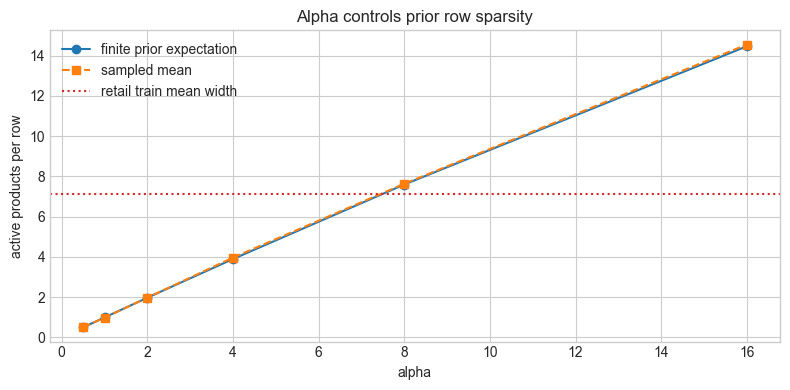

In [19]:
alphas = np.array([0.5, 1.0, 2.0, 4.0, 8.0, 16.0])
prior_records = []
for alpha in alphas:
    prior = IndianBuffetProcessDistribution(K, alpha=alpha, data_format='sparse')
    samples = prior.sampler(seed=int(alpha * 100)).sample(size=4000)
    widths = np.asarray([len(row) for row in samples])
    prior_records.append({
        'alpha': alpha,
        'finite_prior_expected_width': K * alpha / (K + alpha),
        'sampled_mean_width': widths.mean(),
        'sampled_90pct_width': np.quantile(widths, 0.90),
    })
prior_df = pd.DataFrame(prior_records)
display(prior_df.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(prior_df['alpha'], prior_df['finite_prior_expected_width'], 'o-', label='finite prior expectation')
ax.plot(prior_df['alpha'], prior_df['sampled_mean_width'], 's--', label='sampled mean')
ax.axhline(mean_width, color='tab:red', ls=':', label='retail train mean width')
ax.set_xlabel('alpha')
ax.set_ylabel('active products per row')
ax.set_title('Alpha controls prior row sparsity')
ax.legend()
plt.tight_layout()


## 9. Where the IBP model is useful

Good fits:

- product baskets, user permissions, telemetry flags, user interests, document themes, molecular/pathway activations;
- sparse rows where several features can be present at once;
- quick probabilistic baselines for feature popularity and unusual-row triage;
- interpretable sparse fields inside larger PySparkPlug composites or mixtures.

Poor fits without more structure:

- mutually exclusive states: use a categorical model;
- counts or quantities: add count/continuous fields instead of forcing them into binary form;
- strong feature interactions: use mixtures, association models, graphical models, or richer latent structure;
- discovering hidden binary causes from raw continuous vectors alone: this `ibp` class models observed binary rows, so use it as a component or prior, not a complete factor-analysis engine.

The practical recipe:

1. Decide the observational unit: invoice, customer, session, machine, document.
2. Encode each unit as a sparse list of active feature indices.
3. Pick `K` as a truncation upper bound and `alpha` as expected row width.
4. Fit `IndianBuffetProcessEstimator(K, alpha=..., data_format='sparse')`.
5. Inspect `feature_probs` and `beta_params` for probabilities and uncertainty.
6. Use `log_density` for surprise scoring, and posterior predictive samples for model checks.
7. Compose with `CompositeDistribution` and `MixtureDistribution` when context fields or multiple regimes matter.


## Check posterior calibration on held-out data

A Bayesian per-item purchase probability is only trustworthy if it is calibrated: items the model assigns probability $p$ should actually appear in about a fraction $p$ of held-out baskets. We bin the items by their posterior mean $P(\text{item})$ and compare to the empirical frequency in the test period - a reliability check on the Beta posteriors.


In [20]:
pred = np.asarray(basket_model.feature_probs)
emp = test_mat.mean(axis=0)
order = np.argsort(pred)
print(' predicted-prob bin      mean predicted   mean empirical (test)')
for b in np.array_split(order, 5):
    print('   %.3f - %.3f          %.3f            %.3f' %
          (pred[b].min(), pred[b].max(), pred[b].mean(), emp[b].mean()))
print('mean |posterior P(item) - test frequency| over %d items = %.3f' % (len(pred), np.mean(np.abs(pred - emp))))
print('predicted and held-out frequencies track across all bins => the posteriors are calibrated.')

 predicted-prob bin      mean predicted   mean empirical (test)
   0.020 - 0.035          0.030            0.056
   0.035 - 0.038          0.037            0.030
   0.039 - 0.046          0.042            0.045
   0.046 - 0.059          0.052            0.043
   0.060 - 0.180          0.077            0.065
mean |posterior P(item) - test frequency| over 150 items = 0.017
predicted and held-out frequencies track across all bins => the posteriors are calibrated.


## References

- Ghahramani, Z. & Griffiths, T. L. (2005). Infinite latent feature models and the Indian buffet process (https://papers.nips.cc/paper/2005/hash/2ef35a8b78b572a47f56846acbeef5d3-Abstract.html). NeurIPS.
- Griffiths, T. L. & Ghahramani, Z. (2011). The Indian buffet process: an introduction and review (https://jmlr.org/papers/v12/griffiths11a.html). JMLR 12, 1185-1224.
- Doshi-Velez, F., Miller, K. T., Van Gael, J. & Teh, Y. W. (2009). Variational inference for the Indian buffet process (https://proceedings.mlr.press/v5/doshi-velez09a.html). AISTATS.
- Agrawal, R. & Srikant, R. (1994). Fast algorithms for mining association rules (Apriori) (https://www.vldb.org/conf/1994/P487.PDF). VLDB. - the frequent-itemset baseline.


## Exercises and extensions

1. Finite truncation → the IBP limit. Vary the truncation level $K$ and the concentration $\alpha$ of the finite Beta-Bernoulli model and show the number of active features approaches the IBP's $\mathrm{Poisson}(\alpha H_N)$ law (Griffiths & Ghahramani 2011); plot active-features vs $\alpha$.
2. Beat / contrast with Apriori. Run classic Apriori frequent-itemset mining (Agrawal & Srikant) on the baskets and compare its rules to the IBP's latent features; discuss probabilistic features (uncertainty, per-product posteriors) vs hard frequent sets.
3. Surprise-based anomaly scoring. Score baskets by $-\log p(\text{basket})$ under the fitted IBP, rank the tails, and inspect whether the most-surprising baskets are genuinely unusual; tie to anomaly_detection.
4. Variational vs sampled IBP. Compare mixle's IBP to a variational IBP (Doshi-Velez et al. 2009) implementation or a Gibbs sampler on inferred feature count and runtime; discuss the truncation/approximation trade-offs.
